In [1]:
print("hello")

hello


In [2]:
import sys
print(sys.executable)

/scratch/group/arroyave_lab/ifadasamuel/.conda/envs/nimplex_env/bin/python


In [3]:
import os
print("Working directory:", os.getcwd())

Working directory: /scratch/user/ifadasamuel/nimplex_flare_project


In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Polygon


_params = {
    # ---------- Fonts ----------
    'font.family'       : 'DejaVu Serif',
    'mathtext.fontset'  : 'dejavuserif',
    'font.size'         : 10,
    'axes.labelsize'    : 10,
    'text.usetex'       : False,
    #'font.family'       : 'serif',
    #'font.serif'        : ['Times', 'Computer Modern Roman'],
    #'font.size'         : 10,
    #'axes.labelsize'    : 10,
    #'text.usetex'       : False,
    #'text.latex.preamble':
        #r'\usepackage{bm} \usepackage{siunitx} \usepackage{chemformula}',

    # ---------- Lines & markers ----------
    'lines.linewidth'   : 2.0,
    'lines.markersize'  : 6,

    # ---------- Axes ----------
    'axes.linewidth'    : 1.0,
    'axes.labelweight'  : 'normal',
    'axes.formatter.useoffset': False,
    'axes.xmargin'      : 0,
    'axes.ymargin'      : 0,

    # ---------- Ticks ----------
    'xtick.direction'   : 'in',
    'ytick.direction'   : 'in',
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'xtick.top'         : True,
    'ytick.right'       : True,
    'xtick.major.size'  : 4,
    'ytick.major.size'  : 4,
    'xtick.major.width' : 0.6,
    'ytick.major.width' : 0.6,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.minor.size'  : 2,
    'ytick.minor.size'  : 2,

    # ---------- Figure & save ----------
    'figure.dpi'        : 150,
    'savefig.dpi'       : 600,
    'savefig.format'    : 'pdf',
    'savefig.transparent': False,

    # ---------- Legend ----------
   'legend.fontsize': 10,
   'legend.frameon': False,
   'legend.numpoints': 1,
   'legend.handlelength': 2,
   'legend.scatterpoints': 1,
   'legend.labelspacing': 0.5,
   'legend.markerscale': 0.9,
   'legend.handletextpad': 0.5,
   'legend.borderaxespad': 0.5,
   'legend.borderpad': 0.5,
   'legend.columnspacing': 1,

    # ---------- Subplot spacing ----------
    'figure.constrained_layout.use': True,   # replaces manual left/right/top/bottom
    'figure.subplot.left': 0.125,
    'figure.subplot.right': 0.95,
    'figure.subplot.bottom': 0.2,
    'figure.subplot.top': 0.95,
    'axes.autolimit_mode': 'round_numbers',
}

mpl.rcParams.update(_params)

In [5]:
def create_affine_projection_matrix(n_elements, rotation_angle=0.0):
    """Create projection matrix using regular polygon vertices"""
    angles = np.linspace(0, 2 * np.pi, n_elements, endpoint=False) + rotation_angle

    proj_matrix = np.array([
        np.cos(angles),
        np.sin(angles)
    ])
    return proj_matrix


def generate_regular_polygon(n_sides, radius=1, center=(0, 0), rotation_angle=0):
    angles = np.linspace(0, 2 * np.pi, n_sides, endpoint=False) + rotation_angle
    return np.array([[center[0] + radius * np.cos(angle),
                      center[1] + radius * np.sin(angle)] for angle in angles])

In [6]:
import pandas as pd

In [ ]:

df = pd.read_csv("/scratch/user/ifadasamuel/nimplex_flare_project/TiVTaNbMoZrCrHfFeReW_ndiv_20_compositions.csv")

df_1sec = pd.read_pickle("/scratch/user/ifadasamuel/nimplex_flare_project/flare_responses_5at_2y_irr-1sec_dec-over_spect.pkl")
df_1month = pd.read_pickle("/scratch/user/ifadasamuel/nimplex_flare_project/flare_responses_5at_2y_irr-1month_dec-over_spect.pkl")
df_100years = pd.read_pickle("/scratch/user/ifadasamuel/nimplex_flare_project/flare_responses_5at_2y_irr-100yr_dec-over_spect.pkl")

df_1sec_W = pd.read_pickle("/scratch/user/ifadasamuel/nimplex_flare_project/flare_responses_5at_2y_irr-1sec_dec-over_spect.pkl")
df_1month_W = pd.read_pickle("/scratch/user/ifadasamuel/nimplex_flare_project/flare_responses_5at_2y_irr-1month_dec-over_spect.pkl")
df_100years_W = pd.read_pickle("/scratch/user/ifadasamuel/nimplex_flare_project/flare_responses_5at_2y_irr-100yr_dec-over_spect.pkl")

df_eurofer = pd.read_csv("/scratch/user/ifadasamuel/nimplex_flare_project/EUROFER97_flare_DS.csv", index_col=0)

df_eurofer_1sec = df_eurofer[
    (df_eurofer["Flux"] == 8.e+13) &
    (df_eurofer["Irr_time"] == 2) &
    (df_eurofer["Dec_time"] == 3.169e-08)
].drop(['Flux', 'Irr_time', 'Dec_time'], axis=1).mean(numeric_only=True).to_frame().T
df_eurofer_1sec.reset_index(inplace=True, drop=True)
df_eurofer_1sec["composition"] = "EUROFER97"

df_eurofer_1month = df_eurofer[
    (df_eurofer["Flux"] == 8.e+13) &
    (df_eurofer["Irr_time"] == 2) &
    (df_eurofer["Dec_time"] == 1.000000e-01)
].drop(['Flux', 'Irr_time', 'Dec_time'], axis=1).mean(numeric_only=True).to_frame().T
df_eurofer_1month.reset_index(inplace=True, drop=True)
df_eurofer_1month["composition"] = "EUROFER97"

df_eurofer_100years = df_eurofer[
    (df_eurofer["Flux"] == 8.e+13) &
    (df_eurofer["Irr_time"] == 2) &
    (df_eurofer["Dec_time"] == 1.000000e02)
].drop(['Flux', 'Irr_time', 'Dec_time'], axis=1).mean(numeric_only=True).to_frame().T
df_eurofer_100years.reset_index(inplace=True, drop=True)
df_eurofer_100years["composition"] = "EUROFER97"

elements = ['Ti','V','Ta','Nb','Mo','Zr','Cr','Hf','Fe','Re','W']

composition_data = df[elements].values
rotation_angle = np.pi / 11
proj_matrix = create_affine_projection_matrix(11, rotation_angle)
projected_coords = composition_data @ proj_matrix.T

#matches projected_coords)
df['proj0'] = projected_coords[:, 0]
df['proj1'] = projected_coords[:, 1]

Q = generate_regular_polygon(11, radius=1, center=(0, 0), rotation_angle=rotation_angle)

df_eurofer_1sec["M_GAS"] = df_eurofer_1sec["M_H1"] + df_eurofer_1sec["M_H2"] + df_eurofer_1sec["M_H3"] + df_eurofer_1sec["M_He3"] + df_eurofer_1sec["M_He4"]
df_eurofer_1sec["BQ_T"] = df_eurofer_1sec["BQ_A"] + df_eurofer_1sec["BQ_B"] + df_eurofer_1sec["BQ_G"]
df_eurofer_1sec["HT_T"] = df_eurofer_1sec["HT_A"] + df_eurofer_1sec["HT_B"] + df_eurofer_1sec["HT_G"]

df_eurofer_1month["M_GAS"] = df_eurofer_1month["M_H1"] + df_eurofer_1month["M_H2"] + df_eurofer_1month["M_H3"] + df_eurofer_1month["M_He3"] + df_eurofer_1month["M_He4"]
df_eurofer_1month["BQ_T"] = df_eurofer_1month["BQ_A"] + df_eurofer_1month["BQ_B"] + df_eurofer_1month["BQ_G"]
df_eurofer_1month["HT_T"] = df_eurofer_1month["HT_A"] + df_eurofer_1month["HT_B"] + df_eurofer_1month["HT_G"]

df_eurofer_100years["M_GAS"] = df_eurofer_100years["M_H1"] + df_eurofer_100years["M_H2"] + df_eurofer_100years["M_H3"] + df_eurofer_100years["M_He3"] + df_eurofer_100years["M_He4"]
df_eurofer_100years["BQ_T"] = df_eurofer_100years["BQ_A"] + df_eurofer_100years["BQ_B"] + df_eurofer_100years["BQ_G"]
df_eurofer_100years["HT_T"] = df_eurofer_100years["HT_A"] + df_eurofer_100years["HT_B"] + df_eurofer_100years["HT_G"]


df_1sec["M_GAS"] = df_1sec["M_H1"] + df_1sec["M_H2"] + df_1sec["M_H3"] + df_1sec["M_He3"] + df_1sec["M_He4"]
df_1sec["BQ_T"] = df_1sec["BQ_A"] + df_1sec["BQ_B"] + df_1sec["BQ_G"]
df_1sec["HT_T"] = df_1sec["HT_A"] + df_1sec["HT_B"] + df_1sec["HT_G"]

df_1month["M_GAS"] = df_1month["M_H1"] + df_1month["M_H2"] + df_1month["M_H3"] + df_1month["M_He3"] + df_1month["M_He4"]
df_1month["BQ_T"] = df_1month["BQ_A"] + df_1month["BQ_B"] + df_1month["BQ_G"]
df_1month["HT_T"] = df_1month["HT_A"] + df_1month["HT_B"] + df_1month["HT_G"]

df_100years["M_GAS"] = df_100years["M_H1"] + df_100years["M_H2"] + df_100years["M_H3"] + df_100years["M_He3"] + df_100years["M_He4"]
df_100years["BQ_T"] = df_100years["BQ_A"] + df_100years["BQ_B"] + df_100years["BQ_G"]
df_100years["HT_T"] = df_100years["HT_A"] + df_100years["HT_B"] + df_100years["HT_G"]

df_1sec_W["M_GAS"] = df_1sec_W["M_H1"] + df_1sec_W["M_H2"] + df_1sec_W["M_H3"] + df_1sec_W["M_He3"] + df_1sec_W["M_He4"]
df_1sec_W["BQ_T"] = df_1sec_W["BQ_A"] + df_1sec_W["BQ_B"] + df_1sec_W["BQ_G"]
df_1sec_W["HT_T"] = df_1sec_W["HT_A"] + df_1sec_W["HT_B"] + df_1sec_W["HT_G"]

df_1month_W["M_GAS"] = df_1month_W["M_H1"] + df_1month_W["M_H2"] + df_1month_W["M_H3"] + df_1month_W["M_He3"] + df_1month_W["M_He4"]
df_1month_W["BQ_T"] = df_1month_W["BQ_A"] + df_1month_W["BQ_B"] + df_1month_W["BQ_G"]
df_1month_W["HT_T"] = df_1month_W["HT_A"] + df_1month_W["HT_B"] + df_1month_W["HT_G"]

df_100years_W["M_GAS"] = df_100years_W["M_H1"] + df_100years_W["M_H2"] + df_100years_W["M_H3"] + df_100years_W["M_He3"] + df_100years_W["M_He4"]
df_100years_W["BQ_T"] = df_100years_W["BQ_A"] + df_100years_W["BQ_B"] + df_100years_W["BQ_G"]
df_100years_W["HT_T"] = df_100years_W["HT_A"] + df_100years_W["HT_B"] + df_100years_W["HT_G"]

df_W_1sec     = df_1sec_W.loc[["W1"]].copy().reset_index(drop=True)
df_W_1month   = df_1month_W.loc[["W1"]].copy().reset_index(drop=True)
df_W_100years = df_100years_W.loc[["W1"]].copy().reset_index(drop=True)


In [ ]:
import re

elements = ['Ti','V','Ta','Nb','Mo','Zr','Cr','Hf','Fe','Re','W']
pattern = re.compile(r'([A-Z][a-z]?)([\d.]+)')

def parse_comp(s: str) -> pd.Series:
    out = {el: 0.0 for el in elements}
    for el, val in pattern.findall(s):
        if el in out:
            out[el] = float(val)
    return pd.Series(out)

def worse_mask_all(values, comp_val, factor):
        return values > ((100 + factor) / 100) * comp_val

# >>> CHANGED: third entry now points at the explicit pure-W baseline (df_W_*)
lower_is_better = {
    "M_GAS":  [df_1sec,     df_eurofer_1sec,     df_W_1sec],
    "HT_T":   [df_1sec,     df_eurofer_1sec,     df_W_1sec],
    "DPA":    [df_1sec,     df_eurofer_1sec,     df_W_1sec],
    "DOSE_1": [df_1month,   df_eurofer_1month,   df_W_1month],
    "DOSE_2": [df_100years, df_eurofer_100years, df_W_100years],
}

# thresholds to show
factors = np.arange(0,3001, 100)
no_survivors_W = []
no_survivors_EUROFER = []
no_survivors_Common = []

for factor in factors:
    mask_all_good_W = np.ones(len(df_1sec), dtype=bool)
    for c, dfs in lower_is_better.items():
        if c.startswith("DOSE"):
            c = "DOSE"
        mask_all_good_W &= ~worse_mask_all(dfs[0][c].values, dfs[2].iloc[0][c], factor)
    survivors_W: pd.DataFrame = df_1sec.loc[mask_all_good_W].copy()
    survivors_W.reset_index(inplace=True)
    no_survivors_W.append(len(survivors_W))

    mask_all_good_EUROFER = np.ones(len(df_1sec), dtype=bool)
    for c, dfs in lower_is_better.items():
        if c.startswith("DOSE"):
            c = "DOSE"
        mask_all_good_EUROFER &= ~worse_mask_all(dfs[0][c].values, dfs[1].iloc[0][c], factor)
    survivors_EUROFER = df_1sec.loc[mask_all_good_EUROFER].copy()
    survivors_EUROFER.reset_index(inplace=True)
    no_survivors_EUROFER.append(len(survivors_EUROFER))

    new_factor = int((factor / 100) + 1)
    survivors_all = pd.concat([survivors_W, survivors_EUROFER]).reset_index(drop=True)
    survivors_all = survivors_all.loc[:,~survivors_all.columns.duplicated()]
    survivors_elements = survivors_all.composition.apply(parse_comp).astype(float)[elements]
    survivors_joined = survivors_elements.join(survivors_all).reset_index(drop=True)

    df_merged = pd.merge(df, survivors_joined, on=['Ti', 'V', 'Ta', 'Nb', 'Mo', 'Zr', 'Cr', 'Hf', 'Fe', 'Re', 'W'], how='inner')
    df_merged = df_merged.loc[:,~df_merged.columns.duplicated()]

    print(new_factor, len(survivors_W), len(survivors_EUROFER))

In [ ]:
import re

elements = ['Ti','V','Ta','Nb','Mo','Zr','Cr','Hf','Fe','Re','W']
pattern = re.compile(r'([A-Z][a-z]?)([\d.]+)')  # Element + number like Mo0.1

def parse_comp(s: str) -> pd.Series:
    # start all at zero
    out = {el: 0.0 for el in elements}
    for el, val in pattern.findall(s):
        if el in out:
            out[el] = float(val)
    return pd.Series(out)

def worse_mask_all(values, comp_val, factor):
        return values > ((100 + factor) / 100) * comp_val

lower_is_better = {
    "M_GAS":  [df_1sec,     df_eurofer_1sec,     df_W_1sec],
    "HT_T":   [df_1sec,     df_eurofer_1sec,     df_W_1sec],
    "DPA":    [df_1sec,     df_eurofer_1sec,     df_W_1sec],
    "DOSE_1": [df_1month,   df_eurofer_1month,   df_W_1month],
    "DOSE_2": [df_100years, df_eurofer_100years, df_W_100years],
}

# thresholds to show
factors = np.arange(0,3001, 100)
no_survivors_W = []
no_survivors_EUROFER = []
no_survivors_Common = []

for factor in factors:
    mask_all_good_W = np.ones(len(df_1sec), dtype=bool)
    for c, dfs in lower_is_better.items():
        if c.startswith("DOSE"):
            c = "DOSE"
        mask_all_good_W &= ~worse_mask_all(dfs[0][c].values, dfs[2].iloc[0][c], factor)
    survivors_W: pd.DataFrame = df_1sec.loc[mask_all_good_W].copy()
    survivors_W.reset_index(inplace=True)
    no_survivors_W.append(len(survivors_W))

    mask_all_good_EUROFER = np.ones(len(df_1sec), dtype=bool)
    for c, dfs in lower_is_better.items():
        if c.startswith("DOSE"):
            c = "DOSE"
        mask_all_good_EUROFER &= ~worse_mask_all(dfs[0][c].values, dfs[1].iloc[0][c], factor)
    survivors_EUROFER = df_1sec.loc[mask_all_good_EUROFER].copy()
    survivors_EUROFER.reset_index(inplace=True)
    no_survivors_EUROFER.append(len(survivors_EUROFER))

    new_factor = int((factor / 100) + 1)
    survivors_all = pd.concat([survivors_W, survivors_EUROFER]).reset_index(drop=True)
    survivors_all = survivors_all.loc[:,~survivors_all.columns.duplicated()]
    survivors_elements = survivors_all.composition.apply(parse_comp).astype(float)[elements]
    survivors_joined = survivors_elements.join(survivors_all).reset_index(drop=True)

    df_merged = pd.merge(df, survivors_joined, on=['Ti', 'V', 'Ta', 'Nb', 'Mo', 'Zr', 'Cr', 'Hf', 'Fe', 'Re', 'W'], how='inner')
    df_merged = df_merged.loc[:,~df_merged.columns.duplicated()]

    print(new_factor, len(survivors_W), len(survivors_EUROFER))
    # Ensure output folder exists (safe for first run)
    from pathlib import Path

    out_dir = Path("IT2_FLARE_survivors")
    out_dir.mkdir(parents=True, exist_ok=True)

    df_merged.to_csv(f"IT2_FLARE_survivors/FLARE-survivors-5at-{new_factor}x.csv", index=False)

In [10]:
import os
from pathlib import Path

# Redirect matplotlib cache to scratch
os.environ["MPLCONFIGDIR"] = "/scratch/user/ifadasamuel/mpl_cache"

# Create cache folder if it does not exist
Path("/scratch/user/ifadasamuel/mpl_cache").mkdir(parents=True, exist_ok=True)

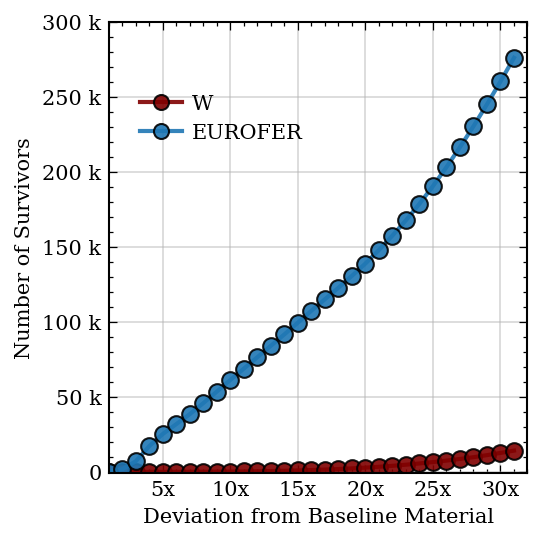

In [ ]:
from matplotlib import colors
from matplotlib.ticker import EngFormatter, MultipleLocator, PercentFormatter


fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
new_factors = np.array(factors) / 100 + 1
ax.plot(new_factors, no_survivors_W, '-o', ms=8, color='maroon', alpha=0.9, mec='black', markerfacecolor=colors.to_rgba('maroon', 0.5), label='W')
ax.plot(new_factors, no_survivors_EUROFER, '-o', ms=8, color='#1F77B4', alpha=0.9, mec='black', markerfacecolor=colors.to_rgba('#1F77B4', 0.9), label='EUROFER')

ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0, symbol="x"))
# >>> CHANGED: y-axis tick spacing scaled up for 5 at% data
ax.yaxis.set_major_locator(MultipleLocator(50000))
ax.yaxis.set_major_formatter(EngFormatter(places=0))


#y-limit raised to fit 5 at% survivor counts (~250-300K instead of ~7K that was usued for IT1 because IT2 has alot of data)
ax.set_ylim(-1000, 300000)
ax.set_xlim(1, 32)

ax.set_xlabel(r"Deviation from Baseline Material")
ax.set_ylabel(r"Number of Survivors")
ax.grid(alpha=0.5)
ax.legend(loc=(0.05, 0.71))


fig.savefig('FIGX2_2.png')

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon


elements = ['Ti','V','Ta','Nb','Mo','Zr','Cr','Hf','Fe','Re','W']
pattern = re.compile(r'([A-Z][a-z]?)([\d.]+)')

def parse_comp(s: str) -> pd.Series:
    out = {el: 0.0 for el in elements}
    for el, val in pattern.findall(s):
        if el in out:
            out[el] = float(val)
    return pd.Series(out)

def worse_mask_all(values, comp_val, factor):
        return values > ((100 + factor) / 100) * comp_val

cols = ["M_GAS","HT_T","DPA","DOSE"]
lower_is_better = {
    "M_GAS":  [df_1sec,     df_eurofer_1sec,     df_W_1sec],
    "HT_T":   [df_1sec,     df_eurofer_1sec,     df_W_1sec],
    "DPA":    [df_1sec,     df_eurofer_1sec,     df_W_1sec],
    "DOSE_1": [df_1month,   df_eurofer_1month,   df_W_1month],
    "DOSE_2": [df_100years, df_eurofer_100years, df_W_100years],
}

# thresholds to show
factors = [900]
no_survivors = []

label_radius = 1.15
R = 1.0
PAD = 0.25
lim = max(R, label_radius) + PAD

for factor in factors:
    fig, ax = plt.subplots(figsize=(3.5, 3.5))

    # EUROFER survivor mask
    mask_all_good = np.ones(len(df_1sec), dtype=bool)
    for c, dfs in lower_is_better.items():
        if c.startswith("DOSE"):
            c = "DOSE"
        mask_all_good &= ~worse_mask_all(dfs[0][c].values, dfs[1].iloc[0][c], factor)
    survivors = df_1sec.loc[mask_all_good].copy()
    survivors.reset_index(inplace=True)

    survivors_elements = survivors.composition.apply(parse_comp).astype(float)[elements]
    survivors_joined = survivors_elements.join(survivors).reset_index(drop=True)
    df_merged = pd.merge(df, survivors_joined, on=elements, how='inner')
    df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()]

    # base polygon + element labels
    polygon = Polygon(Q, edgecolor='gray', facecolor='lightgray', linewidth=2, alpha=0.3)
    ax.add_patch(polygon)

    for i, element in enumerate(elements):
        angle = (2 * np.pi * i / 11) + rotation_angle
        x = label_radius * np.cos(angle)
        y = label_radius * np.sin(angle)
        ax.text(x, y, element, fontsize=12, ha='center', va='center',
                fontweight='bold', color='black', clip_on=False)

    ax.scatter(df['proj0'], df['proj1'],
               c='lightgray', s=20, alpha=0.9, edgecolors='none')

    ax.scatter(df_merged['proj0'], df_merged['proj1'], color='#1F77B4',
               s=20, alpha=0.9, edgecolors='black')

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.axis('off')

    deviation = int((factor / 100) + 1)
    print(deviation, len(survivors))
    plt.savefig(f"Responses_filter-All_IT2_EUROFER_{deviation}.png", dpi=600, bbox_inches='tight')
    plt.close()

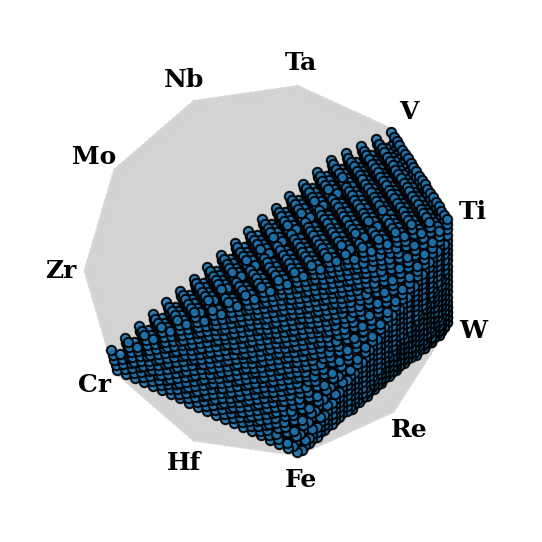

In [ ]:
import re

elements = ['Ti','V','Ta','Nb','Mo','Zr','Cr','Hf','Fe','Re','W']
pattern = re.compile(r'([A-Z][a-z]?)([\d.]+)')  # Element + number like Mo0.1

def parse_comp(s: str) -> pd.Series:
    out = {el: 0.0 for el in elements}
    for el, val in pattern.findall(s):
        if el in out:
            out[el] = float(val)
    return pd.Series(out)

def worse_mask_all(values, comp_val, factor):
        return values > ((100 + factor) / 100) * comp_val

lower_is_better = {
    "M_GAS":  [df_1sec,     df_eurofer_1sec,     df_W_1sec],
    "HT_T":   [df_1sec,     df_eurofer_1sec,     df_W_1sec],
    "DPA":    [df_1sec,     df_eurofer_1sec,     df_W_1sec],
    "DOSE_1": [df_1month,   df_eurofer_1month,   df_W_1month],
    "DOSE_2": [df_100years, df_eurofer_100years, df_W_100years],
}

factors = [900]
no_survivors_W = []
no_survivors_EUROFER = []
no_survivors_Common = []

label_radius = 1.15
R = 1.0
PAD = 0.25
lim = max(R, label_radius) + PAD

for factor in factors:
    fig, ax = plt.subplots(figsize=(3.5, 3.5))

    polygon = Polygon(Q, edgecolor='gray', facecolor='lightgray', linewidth=2, alpha=0.3)
    ax.add_patch(polygon)

    mask_all_good_W = np.ones(len(df_1sec), dtype=bool)
    for c, dfs in lower_is_better.items():
        if c.startswith("DOSE"):
            c = "DOSE"
        mask_all_good_W &= ~worse_mask_all(dfs[0][c].values, dfs[2].iloc[0][c], factor)
    survivors_W: pd.DataFrame = df_1sec.loc[mask_all_good_W].copy()
    survivors_W.reset_index(inplace=True)
    no_survivors_W.append(len(survivors_W))

    mask_all_good_EUROFER = np.ones(len(df_1sec), dtype=bool)
    for c, dfs in lower_is_better.items():
        if c.startswith("DOSE"):
            c = "DOSE"
        mask_all_good_EUROFER &= ~worse_mask_all(dfs[0][c].values, dfs[1].iloc[0][c], factor)
    survivors_EUROFER = df_1sec.loc[mask_all_good_EUROFER].copy()
    survivors_EUROFER.reset_index(inplace=True)
    no_survivors_EUROFER.append(len(survivors_EUROFER))

    new_factor = int((factor / 100) + 1)
    survivors_all = pd.concat([survivors_W, survivors_EUROFER]).reset_index(drop=True)
    survivors_all = survivors_all.loc[:, ~survivors_all.columns.duplicated()]
    survivors_elements = survivors_all.composition.apply(parse_comp).astype(float)[elements]
    survivors_joined = survivors_elements.join(survivors_all).reset_index(drop=True)

    df_merged = pd.merge(df, survivors_joined, on=elements, how='inner')
    df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()]

    for i, element in enumerate(elements):
        angle = (2 * np.pi * i / 11) + rotation_angle
        x = label_radius * np.cos(angle)
        y = label_radius * np.sin(angle)
        ax.text(x, y, element, fontsize=12, ha='center', va='center',
                fontweight='bold', color='black', clip_on=False)

    ax.scatter(df['proj0'], df['proj1'],
               c='lightgray', s=20, alpha=0.9, edgecolors='none')

    ax.scatter(df_merged['proj0'], df_merged['proj1'], color='#1F77B4',
               s=20, alpha=0.9, edgecolors='black')

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.axis('off')

10 210


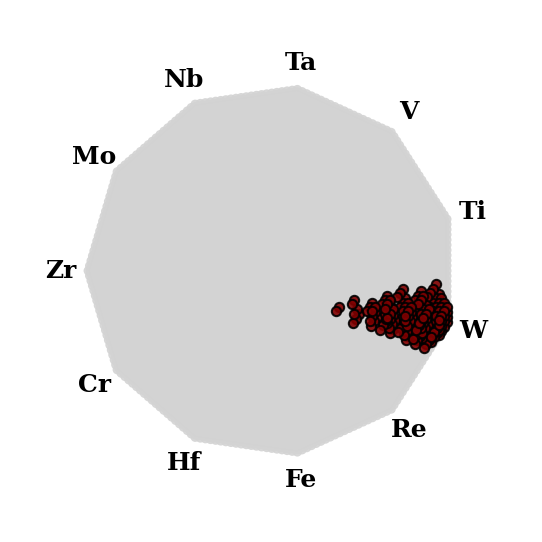

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon


elements = ['Ti','V','Ta','Nb','Mo','Zr','Cr','Hf','Fe','Re','W']
pattern = re.compile(r'([A-Z][a-z]?)([\d.]+)')

def parse_comp(s: str) -> pd.Series:
    out = {el: 0.0 for el in elements}
    for el, val in pattern.findall(s):
        if el in out:
            out[el] = float(val)
    return pd.Series(out)

def worse_mask_all(values, comp_val, factor):
        return values > ((100 + factor) / 100) * comp_val

cols = ["M_GAS","HT_T","DPA","DOSE"]
lower_is_better = {
    "M_GAS":  [df_1sec,     df_eurofer_1sec,     df_W_1sec],
    "HT_T":   [df_1sec,     df_eurofer_1sec,     df_W_1sec],
    "DPA":    [df_1sec,     df_eurofer_1sec,     df_W_1sec],
    "DOSE_1": [df_1month,   df_eurofer_1month,   df_W_1month],
    "DOSE_2": [df_100years, df_eurofer_100years, df_W_100years],
}

factors = [900]
no_survivors = []

label_radius = 1.15
R = 1.0
PAD = 0.25
lim = max(R, label_radius) + PAD

for factor in factors:
    fig, ax = plt.subplots(figsize=(3.5, 3.5))

    # W survivor mask (uses dfs[2] = pure-W baseline)
    mask_all_good = np.ones(len(df_1sec), dtype=bool)
    for c, dfs in lower_is_better.items():
        if c.startswith("DOSE"):
            c = "DOSE"
        mask_all_good &= ~worse_mask_all(dfs[0][c].values, dfs[2].iloc[0][c], factor)
    survivors = df_1sec.loc[mask_all_good].copy()
    survivors.reset_index(inplace=True)

    survivors_elements = survivors.composition.apply(parse_comp).astype(float)[elements]
    survivors_joined = survivors_elements.join(survivors).reset_index(drop=True)
    df_merged = pd.merge(df, survivors_joined, on=elements, how='inner')
    df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()]

    # base polygon + element labels
    polygon = Polygon(Q, edgecolor='gray', facecolor='lightgray', linewidth=2, alpha=0.3)
    ax.add_patch(polygon)

    for i, element in enumerate(elements):
        angle = (2 * np.pi * i / 11) + rotation_angle
        x = label_radius * np.cos(angle)
        y = label_radius * np.sin(angle)
        ax.text(x, y, element, fontsize=12, ha='center', va='center',
                fontweight='bold', color='black', clip_on=False)

    ax.scatter(df['proj0'], df['proj1'],
               c='lightgray', s=20, alpha=0.9, edgecolors='none')

    ax.scatter(df_merged['proj0'], df_merged['proj1'], color='maroon',
               s=20, alpha=0.9, edgecolors='black')

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.axis('off')

    deviation = int((factor / 100) + 1)
    print(deviation, len(survivors))
    plt.savefig(f"Responses_filter-All_IT2_W_{deviation}.png", dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()